In [50]:
import stable_worldmodel as swm
from stable_worldmodel.policy import PlanConfig, WorldModelPolicy
from stable_worldmodel.solver import CEMSolver
from stable_worldmodel.wm.utils import load_pretrained
from random import randint
import torch
import cv2
import gymnasium as gym              
from PIL import Image

In [13]:
dataset = swm.data.load_dataset(
    'tworooms-fov.lance',
    num_steps=2,
    frameskip=1,
    #keys_to_load=['pixels', 'action', 'state', 'target'],
)

In [14]:
episode = dataset.load_episode(0)

In [46]:
env = gym.make('swm/TwoRoom-v1', render_mode='rgb_array')

/tmp/ipykernel_493713/3715590303.py:3: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(initial, mode='RGB')


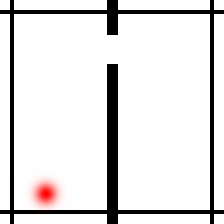

In [76]:
env.reset(options={'proprio': episode['state'][0].numpy()})
initial = env.render()
img = Image.fromarray(initial, mode='RGB')
img.show()

/tmp/ipykernel_493713/2082960860.py:3: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(goal, mode='RGB')


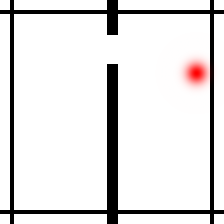

In [78]:
env.reset(options={'proprio': episode['goal_state'][0].numpy()})
goal = env.render()
img = Image.fromarray(goal, mode='RGB')
img.show()

In [6]:
device = 'cuda'
model = load_pretrained('tworoom-fov/training-0-alt.pt').to(device).eval()
model.requires_grad_(False)

num_envs=1

world = swm.World(
    'swm/TwoRoom-v1',
    num_envs=num_envs,
    image_shape=(224, 224),
    max_episode_steps=100,
)

solver = CEMSolver(
    model=model,
    num_samples=300,
    n_steps=10,
    device=device,
)

policy = WorldModelPolicy(
    solver=solver,
    config=PlanConfig(
        horizon=2,
        receding_horizon=2
    ),
)

max_episode = 10000
#episodes_idx = [10]
episodes_idx = [randint(0, max_episode-1) for _ in range(num_envs)]
#min_episode_length = min([dataset.load_episode(ep)['action'].shape[0] for ep in episodes_idx])

world.set_policy(policy)
results = world.evaluate(
    dataset=dataset,
    episodes_idx=episodes_idx,
    start_steps=[0 for _ in range(num_envs)],
    goal_offset=25,
    eval_budget=50,
    video='videos/tworooms',
    callables=[
        {'method': '_set_state', 'args': {'state': {'value': 'state'}}},
        {
            'method': '_set_goal_state',
            'args': {'goal_state': {'value': 'goal_state'}},
        },
    ],
)
world.close()

print(results)

CEM solve time: 5.9802 seconds
CEM solve time: 5.9800 seconds
CEM solve time: 5.9967 seconds
CEM solve time: 5.9989 seconds
CEM solve time: 6.0050 seconds
CEM solve time: 6.0058 seconds
CEM solve time: 6.0114 seconds
CEM solve time: 6.0140 seconds
CEM solve time: 6.0173 seconds
CEM solve time: 6.0324 seconds
CEM solve time: 6.0410 seconds
CEM solve time: 6.0458 seconds
CEM solve time: 6.0473 seconds
CEM solve time: 6.0502 seconds
CEM solve time: 6.0534 seconds
CEM solve time: 6.0555 seconds
CEM solve time: 6.0570 seconds
CEM solve time: 6.0576 seconds
CEM solve time: 6.0617 seconds
CEM solve time: 6.0628 seconds
CEM solve time: 6.0615 seconds
CEM solve time: 6.0699 seconds
CEM solve time: 6.0821 seconds
CEM solve time: 6.0841 seconds


/.uv/python_install/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/subprocess.py:1885: RuntimeWarning: lancedb fork support is experimental: the internal async runtime has been reset in the forked child, but a small chance of deadlock remains if other state was mid-operation at fork time. The 'forkserver' or 'spawn' multiprocessing start method is likely a safer alternative.
  self.pid = _fork_exec(


CEM solve time: 6.0849 seconds
{'success_rate': 0.0, 'episode_successes': array([False]), 'seeds': None}
